# Preparación del Entorno de Trabajo en Python

Antes de abordar la visualización y resolución del problema de optimización, es necesario preparar el entorno de trabajo en Python. Esto implica importar las bibliotecas necesarias que permitirán tanto la formulación y resolución del problema de optimización como su visualización gráfica. Las bibliotecas utilizadas son NumPy, Matplotlib y CVXPY.

### Importación de Bibliotecas:

1. **NumPy**:
   - Importamos `numpy` con el alias `np`.
   - NumPy es una biblioteca fundamental para la computación científica en Python, proporcionando soporte para arrays y matrices, junto con una colección de funciones matemáticas para operar en estos arrays.

2. **Matplotlib**:
   - Importamos `matplotlib.pyplot` con el alias `plt`.
   - Matplotlib es una biblioteca de gráficos 2D en Python que produce figuras de calidad en una variedad de formatos impresos y entornos interactivos.

3. **CVXPY**:
   - Importamos `cvxpy` con el alias `cp`.
   - CVXPY es una biblioteca de Python para la optimización convexa que facilita la formulación y resolución de problemas matemáticos de optimización.

4. **Configuración de Matplotlib**:
   - Utilizamos `%matplotlib inline` para configurar el entorno de Jupyter Notebook, asegurando que los gráficos de Matplotlib se muestren directamente en el notebook.

---
## Problema 1. Función a Trozos

Se desea encontrar el mínimo de la siguiente función a trozos:

$$
f(x)=\begin{cases}
x-4 & \text{para } 1\leq x\leq 4 \\
(x-2)^2-4 & \text{en otro caso}
\end{cases}
$$

### Descripción del Problema

Esta función presenta un desafío debido a su naturaleza a trozos y a la no convexidad en todo su dominio. La función se divide en dos segmentos:

1. **Segmento Lineal**: Para $1 \leq x \leq 4$, la función es lineal, representada por $f(x) = x - 4$.
2. **Segmento Cuadrático**: Para $x < 1$ o $x > 4$, la función es cuadrática, representada por $f(x) = (x-2)^2 - 4$.

### Objetivo

El objetivo es resolver y visualizar el problema de optimización para cada segmento por separado y luego comparar los resultados para determinar el mínimo global. Es importante notar que cada segmento es convexo en su propio dominio, lo que facilita la aplicación de métodos de optimización convexa para cada parte.


In [2]:
import cvxpy as cp
import numpy as np

# Resolución para la función lineal
x1 = cp.Variable()
objective1 = cp.Minimize(x1 - 4)
constraints1 = [1 <= x1, x1 <= 4]
prob1 = cp.Problem(objective1, constraints1)
prob1.solve()

# Resolución para la función cuadrática (x < 1)
x2 = cp.Variable()
objective2 = cp.Minimize(cp.square(x2 - 2) - 4)
constraints2 = [x2 <= 1]
prob2 = cp.Problem(objective2, constraints2)
prob2.solve()

# Resolución para la función cuadrática (x > 4)
x3 = cp.Variable()
objective3 = cp.Minimize(cp.square(x3 - 2) - 4)
constraints3 = [x3 >= 4]
prob3 = cp.Problem(objective3, constraints3)
prob3.solve()

# Comparar los resultados
min_values = [prob1.value, prob2.value, prob3.value]
min_x_values = [x1.value, x2.value, x3.value]
min_value = min(min_values)
min_x = min_x_values[min_values.index(min_value)]

print(f"El valor mínimo de f(x) es: {min_value}")
print(f"El valor de x en el mínimo es: {min_x}")

El valor mínimo de f(x) es: -3.0
El valor de x en el mínimo es: 1.0


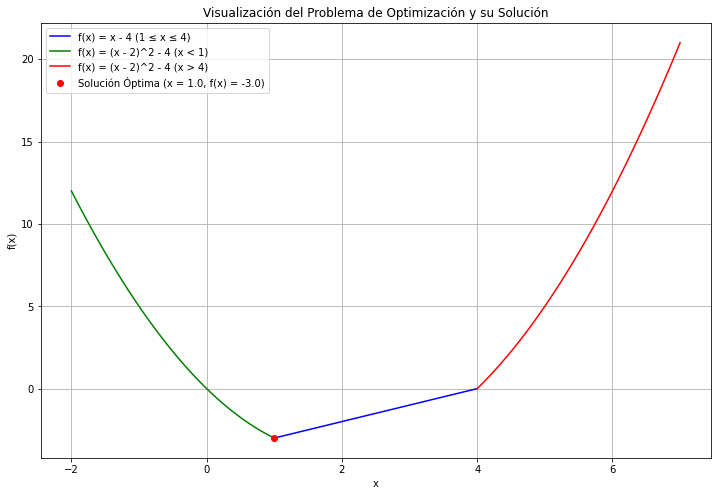

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

# Crear un rango de valores de x para graficar la función
x_vals_lineal = np.linspace(1, 4, 100)
x_vals_cuad1 = np.linspace(-2, 1, 100)
x_vals_cuad2 = np.linspace(4, 7, 100)

# Calcular valores de la función
function_vals_lineal = x_vals_lineal - 4
function_vals_cuad1 = (x_vals_cuad1 - 2)**2 - 4
function_vals_cuad2 = (x_vals_cuad2 - 2)**2 - 4

# Crear la gráfica
plt.figure(figsize=(12, 8))

# Dibujar la función lineal
plt.plot(x_vals_lineal, function_vals_lineal, label='f(x) = x - 4 (1 ≤ x ≤ 4)', color='blue')

# Dibujar la función cuadrática (x < 1)
plt.plot(x_vals_cuad1, function_vals_cuad1, label='f(x) = (x - 2)^2 - 4 (x < 1)', color='green')

# Dibujar la función cuadrática (x > 4)
plt.plot(x_vals_cuad2, function_vals_cuad2, label='f(x) = (x - 2)^2 - 4 (x > 4)', color='red')

# Dibujar la solución óptima
plt.plot(min_x, min_value, 'ro', label=f'Solución Óptima (x = {min_x}, f(x) = {min_value})')

# Configurar las etiquetas y título del gráfico
plt.title('Visualización del Problema de Optimización y su Solución')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()



## Resolución Paso a Paso del Problema de Optimización para una Función a Trozos

Se busca el mínimo de la siguiente función a trozos, que es convexa pero no diferenciable en todo su dominio:

$$
f(x)=\begin{cases}
x-4 & \text{para } 1\leq x\leq 4 \\
(x-2)^2-4 & \text{en otro caso}
\end{cases}
$$

### Paso 1: Resolver para la Función Lineal en el Rango $1 \leq x \leq 4$
Se aborda primero el segmento lineal de la función, $f(x) = x - 4$, aplicable cuando $1 \leq x \leq 4$. La solución de este segmento se encuentra utilizando métodos de optimización convexa, apropiados debido a la convexidad de la función en este rango.

### Paso 2: Resolver para la Función Cuadrática en los Rangos $x < 1$ y $x > 4$
A continuación, se examina el segmento cuadrático, $f(x) = (x-2)^2 - 4$, que se aplica cuando $x < 1$ o $x > 4$. Al igual que con el segmento lineal, este segmento es convexo, y se resuelve utilizando métodos de optimización convexa para cada uno de estos rangos.

### Paso 3: Comparar los Resultados y Determinar el Mínimo Global
Finalmente, se comparan los mínimos obtenidos en los segmentos lineal y cuadrático para determinar el mínimo global de la función. El valor más bajo de estos mínimos representa el mínimo global de la función completa.

### Conclusión
Este enfoque permite abordar de manera eficiente la optimización de una función convexa a trozos. A pesar de su falta de diferenciabilidad en todo el dominio, la convexidad de la función facilita la aplicación de métodos de optimización convexa para encontrar su mínimo global.

---
## Problema 2. Optimización en Intervalo

Se busca encontrar el valor mínimo de la función cuadrática $f(x)$ en un intervalo específico. La función está definida como:

$$ f(x) = (x-2)^2 - 4 $$

y el dominio de interés para este problema es el intervalo $\mathcal{S} = [3, 5]$.

### Descripción del Problema

La función $f(x) = (x-2)^2 - 4$ es una parábola cuyo vértice se encuentra en $x = 2$. Sin embargo, dado que estamos interesados en encontrar el mínimo dentro del intervalo $\mathcal{S} = [3, 5]$, el problema se convierte en uno de optimización restringida.

### Objetivo

El objetivo es determinar y visualizar el valor de $x$ dentro del intervalo $\mathcal{S}$ que minimiza $f(x)$, así como calcular el valor mínimo que alcanza $f(x)$ en este intervalo.

In [9]:
# Definición de la variable de optimización
x = cp.Variable()

# Definición de la función objetivo
objective = cp.Minimize((x - 2)**2 - 4)

# Definición de las restricciones
constraints = [3 <= x, x <= 5]

# Definición y resolución del problema
prob = cp.Problem(objective, constraints)
prob.solve()

# Resultados
x_value = x.value
min_value = prob.value

print("Valor de x que minimiza la función:", x_value)
print("Valor mínimo de la función:", min_value)


Valor de x que minimiza la función: 3.0
Valor mínimo de la función: -3.0


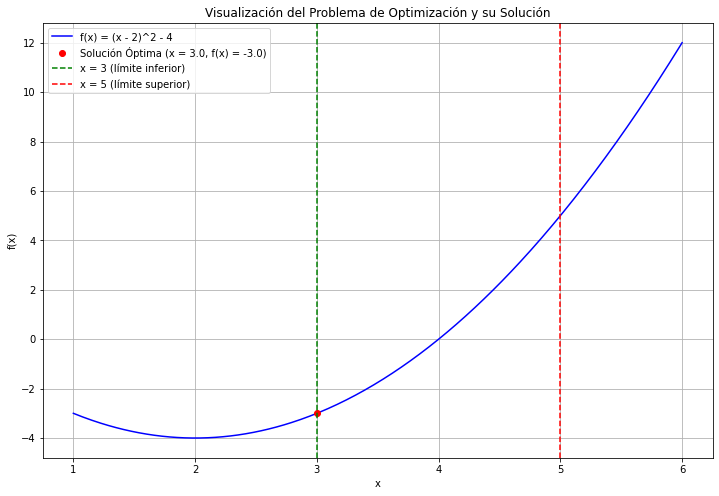

In [13]:
# Crear un rango de valores de x para graficar la función
x_vals = np.linspace(1, 6, 400)
function_vals = (x_vals - 2)**2 - 4

# Crear la gráfica
plt.figure(figsize=(12, 8))

# Dibujar la función
plt.plot(x_vals, function_vals, label='f(x) = (x - 2)^2 - 4', color='blue')

# Dibujar la solución óptima
plt.plot(x_value, min_value, 'ro', label=f'Solución Óptima (x = {x_value}, f(x) = {min_value})')

# Dibujar las restricciones (límites del intervalo [3, 5])
plt.axvline(x=3, color='green', linestyle='--', label='x = 3 (límite inferior)')
plt.axvline(x=5, color='red', linestyle='--', label='x = 5 (límite superior)')

# Configurar las etiquetas y título del gráfico
plt.title('Visualización del Problema de Optimización y su Solución')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

---
## Problema 3. Optimización con varias restricciones

Se busca minimizar la función cuadrática $f(x_1, x_2)$, definida sobre un conjunto específico de restricciones. La función y el conjunto de restricciones son los siguientes:

### Función Objetivo
$$
f(x_1, x_2) = (x_1 - 3)^2 + (x_2 - 2)^2
$$

Esta es una función cuadrática, cuyo mínimo global queremos encontrar. El término $(x_1 - 3)^2 + (x_2 - 2)^2$ representa la distancia al cuadrado entre cualquier punto $(x_1, x_2)$ y el punto $(3, 2)$ en el plano. Este problema es un clásico ejemplo de optimización cuadrática con restricciones lineales y no lineales, que se puede resolver utilizando métodos de optimización convexa.

### Conjunto de Restricciones $\mathcal{S}$
El dominio de la función está limitado por las siguientes restricciones:

1. **Restricción Circular**: $x_1^2 + x_2^2 - 5 \leq 0$. Esta restricción define una región circular en el plano, con un radio que se extiende hasta el punto donde la suma de los cuadrados de $x_1$ y $x_2$ es igual a 5.

2. **Restricción Lineal**: $x_1 + 2x_2 - 4 \leq 0$. Esta restricción representa una línea en el plano. Los puntos válidos deben estar en o por debajo de esta línea.

3. **Restricciones de No Negatividad**: 
   - $-x_1 \leq 0$ indica que $x_1$ debe ser no negativo.
   - $-x_2 \leq 0$ indica que $x_2$ debe ser no negativo.

### Objetivo 
El objetivo es encontrar y visualizar los valores de $x_1$ y $x_2$ que minimicen la función $f(x_1, x_2)$, sujetos a las restricciones mencionadas. Esto implica buscar el punto más cercano al punto $(3, 2)$ dentro del conjunto de restricciones definido.

In [5]:
# Definición de las variables de optimización
x1 = cp.Variable()
x2 = cp.Variable()

# Definición de la función objetivo
objective = cp.Minimize((x1 - 3)**2 + (x2 - 2)**2)

# Definición de las restricciones
constraints = [
    x1**2 + x2**2 - 5 <= 0,  # Restricción circular
    x1 + 2*x2 - 4 <= 0,      # Restricción lineal
    -x1 <= 0,                # No negatividad para x1
    -x2 <= 0                 # No negatividad para x2
]

# Definición y resolución del problema
prob = cp.Problem(objective, constraints)
prob.solve()

# Resultados
x1_value = x1.value
x2_value = x2.value
min_value = prob.value

print(f"Valor de x1: {x1_value:.2f}")
print(f"Valor de x2: {x2_value:.2f}")
print(f"Valor mínimo de la función: {min_value:.2f}")

Valor de x1: 2.00
Valor de x2: 1.00
Valor mínimo de la función: 2.00


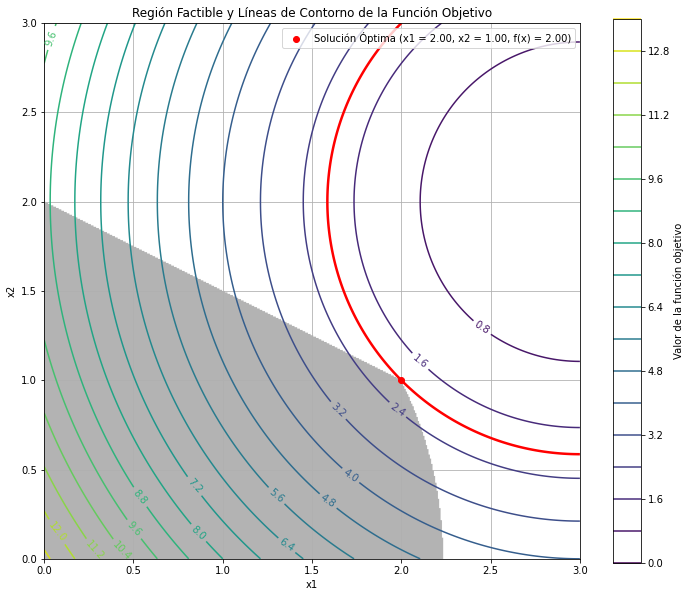

In [6]:
# Crear un grid de puntos para evaluar las restricciones y la función objetivo
x1_vals = np.linspace(0, 3, 400)
x2_vals = np.linspace(0, 3, 400)
x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)

# Evaluar las restricciones para determinar la región factible
constraint1 = x1_grid**2 + x2_grid**2 <= 5
constraint2 = x1_grid + 2*x2_grid <= 4
constraint3 = x1_grid >= 0
constraint4 = x2_grid >= 0

# Crear la función objetivo para las líneas de contorno
objective = (x1_grid - 3)**2 + (x2_grid - 2)**2

# Iniciar la figura de matplotlib
plt.figure(figsize=(12, 10))

# Dibujar la región factible
plt.imshow(((constraint1) & (constraint2) & (constraint3) & (constraint4)).astype(int), 
           extent=(x1_grid.min(), x1_grid.max(), x2_grid.min(), x2_grid.max()), 
           origin="lower", cmap="Greys", alpha=0.3)

# Dibujar las líneas de contorno de la función objetivo
contours = plt.contour(x1_grid, x2_grid, objective, levels=20, cmap="viridis")
plt.clabel(contours, inline=1, fontsize=10)

# Dibujar la curva de nivel correspondiente al valor mínimo
plt.contour(x1_grid, x2_grid, objective, levels=[min_value], colors='red', linewidths=2.5)

# Dibujar la solución óptima con la etiqueta correcta
plt.plot(x1_value, x2_value, 'ro', label=f'Solución Óptima (x1 = {x1_value:.2f}, x2 = {x2_value:.2f}, f(x) = {min_value:.2f})')

# Configurar las etiquetas y título del gráfico
plt.title('Región Factible y Líneas de Contorno de la Función Objetivo')
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(contours, label='Valor de la función objetivo')
plt.legend()
plt.grid(True)
plt.show()

---
## Problema 4. Optimización con varias restricciones

Se busca minimizar la función cuadrática $f(x_1, x_2)$, definida sobre un conjunto específico de restricciones. La función y el conjunto de restricciones son los siguientes:

### Función Objetivo
$$
f(x_1, x_2) = (x_1 - 1)^2 + (x_2 - 1)^2
$$

Esta función representa la distancia euclidiana al cuadrado entre cualquier punto $(x_1, x_2)$ y el punto $(1, 1)$ en el plano.

### Conjunto de Restricciones $\mathcal{S}$
El dominio de la función está limitado por las siguientes restricciones:

1. **Restricción Circular**: $x_1^2 + x_2^2 - 5 \leq 0$. Esta restricción define una región circular con centro en el origen y un radio que alcanza hasta donde la suma de los cuadrados de $x_1$ y $x_2$ es igual a 5.

2. **Restricción Lineal**: $x_1 + 2x_2 - 4 \leq 0$. Esta restricción representa una línea en el plano. Los puntos válidos deben estar en o por debajo de esta línea.

3. **Restricciones de No Negatividad**: 
   - $-x_1 \leq 0$ indica que $x_1$ debe ser no negativo.
   - $-x_2 \leq 0$ indica que $x_2$ debe ser no negativo.

### Objetivo 
El objetivo es encontrar los valores de $x_1$ y $x_2$ que minimicen la función $f(x_1, x_2)$, sujetos a las restricciones mencionadas. Esto implica buscar el punto más cercano al punto $(1, 1)$ dentro del conjunto de restricciones definido.

Este problema es un clásico ejemplo de optimización cuadrática con restricciones lineales y no lineales, que se puede resolver utilizando métodos de optimización convexa.


In [7]:
# Definición de las variables de optimización
x1 = cp.Variable()
x2 = cp.Variable()

# Definición de la función objetivo
objective = cp.Minimize((x1 - 1)**2 + (x2 - 1)**2)

# Definición de las restricciones
constraints = [
    x1**2 + x2**2 - 5 <= 0,  # Restricción circular
    x1 + 2*x2 - 4 <= 0,      # Restricción lineal
    -x1 <= 0,                # No negatividad para x1
    -x2 <= 0                 # No negatividad para x2
]

# Definición y resolución del problema
prob = cp.Problem(objective, constraints)
prob.solve()

# Resultados
x1_value = x1.value
x2_value = x2.value
min_value = prob.value

print("Valor de x1 que minimiza la función:", x1_value)
print("Valor de x2 que minimiza la función:", x2_value)
print("Valor mínimo de la función:", min_value)

Valor de x1 que minimiza la función: 1.0000071067125775
Valor de x2 que minimiza la función: 1.0000002976759637
Valor mínimo de la función: 5.059397463898291e-11


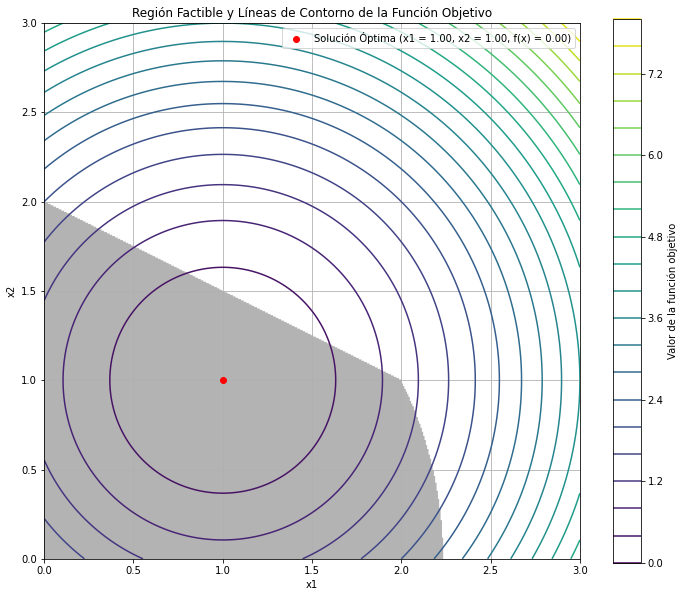

In [8]:
# Crear un rango de valores de x para graficar la función
x1_vals = np.linspace(0, 3, 400)
x2_vals = np.linspace(0, 3, 400)
x1_grid, x2_grid = np.meshgrid(x1_vals, x2_vals)

# Evaluar las restricciones para determinar la región factible
constraint1 = x1_grid**2 + x2_grid**2 <= 5
constraint2 = x1_grid + 2 * x2_grid <= 4
constraint3 = x1_grid >= 0
constraint4 = x2_grid >= 0

# Crear la función objetivo para las líneas de contorno
objective = (x1_grid - 1)**2 + (x2_grid - 1)**2

# Iniciar la figura de matplotlib
plt.figure(figsize=(12, 10))

# Dibujar la región factible
plt.imshow(((constraint1) & (constraint2) & (constraint3) & (constraint4)).astype(int), 
           extent=(x1_grid.min(), x1_grid.max(), x2_grid.min(), x2_grid.max()), 
           origin="lower", cmap="Greys", alpha=0.3)

# Dibujar las líneas de contorno de la función objetivo
contours = plt.contour(x1_grid, x2_grid, objective, levels=20, cmap="viridis")

# Resaltar la curva de nivel que corresponde al valor mínimo
min_contour = plt.contour(x1_grid, x2_grid, objective, levels=[min_value], colors='red')
plt.clabel(min_contour, inline=1, fontsize=10, fmt='%.2f')

# Dibujar la solución óptima con la etiqueta correcta
plt.plot(x1_value, x2_value, 'ro', label=f'Solución Óptima (x1 = {x1_value:.2f}, x2 = {x2_value:.2f}, f(x) = {min_value:.2f})')

# Configurar leyendas y títulos
plt.title('Región Factible y Líneas de Contorno de la Función Objetivo')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.colorbar(contours, label='Valor de la función objetivo')
plt.grid(True)
plt.show()